In [1]:
import pandas as pd
import gc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeClassifier
import warnings
from dotenv import load_dotenv
from sqlalchemy import create_engine
import os

In [2]:
names = ['Ciudad','Fecha', 'Producto','Tipo_Producto', 'Cantidad', 'Precio_Unitario', 'Tipo_Venta',
         'Tipo_Cliente', 'Descuento', 'Costo_Envio', 'Venta_Total']
try:
    df = pd.read_csv('ventas.csv', encoding='latin-1', header=0, names=names)
except:
    df = pd.read_csv('ventas.csv', encoding='utf-8', header=0, names=names)

print(df.tail(4))

           Ciudad       Fecha     Producto       Tipo_Producto Cantidad  \
1249996   Mendoza  2025-11-05          Pan           Abarrotes      9.0   
1249997   Chicago  2025-10-27      Gaseosa               Snack      7.0   
1249998   Houston  2025-10-27       Cereal               Snack      9.0   
1249999  Trujillo  2025-11-03  Mantequilla  Alimento_Percedero      2.0   

        Precio_Unitario    Tipo_Venta Tipo_Cliente Descuento Costo_Envio  \
1249996          3123.0  Distribuidor  Corporativo      0.05         0.0   
1249997          3821.0  Distribuidor    Mayorista       0.2         0.0   
1249998          4417.0   Call_Center     Gobierno      0.15     10000.0   
1249999          1772.0  Distribuidor    Minorista       0.0         0.0   

        Venta_Total  
1249996     26701.0  
1249997     21397.0  
1249998     43790.0  
1249999      3544.0  


## Fix (Mojibake) for text

In [3]:
def fix_characters(texto):
    if isinstance(texto,str):
        try:
            return texto.encode('latin-1').decode('utf-8')
        except:
            return texto
    return texto

cols_text = ['Ciudad', 'Producto', 'Tipo_Producto', 'Tipo_Venta', 'Tipo_Cliente' ]

for col in cols_text:
    missing_before = df[col].isnull().sum()
    values = df[col].unique()
    fixed_map = {}

    for val in values:
        if pd.isna(val):
            fixed_map[val] = val
        else:
            fixed_map[val] = fix_characters(val)

    df[col] = df[col].map(fixed_map)

    after_missing = df[col].isnull().sum()

    if after_missing == missing_before:
        print(f"Fixed successfully for '{col}'")
    else:
        diff = after_missing - missing_before
        print(f"Please  Check again: '{col}' lost '{diff}' values ")
    df[col] = df[col].astype('category')
gc.collect()
print(df.head())

    

Fixed successfully for 'Ciudad'
Fixed successfully for 'Producto'
Fixed successfully for 'Tipo_Producto'
Fixed successfully for 'Tipo_Venta'
Fixed successfully for 'Tipo_Cliente'
         Ciudad       Fecha Producto Tipo_Producto Cantidad Precio_Unitario  \
0      Santiago  2025-10-30    Arepa     Abarrotes      2.0          3681.0   
1       Córdoba  2025-11-17    Arepa     Abarrotes      7.0          2321.0   
2  Barranquilla  2025-10-22    Leche        Lácteo      9.0          3540.0   
3      New York  2025-10-20   Cereal        Lácteo      3.0          3287.0   
4        Madrid  2025-10-20    Leche         Hogar      2.0          3414.0   

      Tipo_Venta Tipo_Cliente Descuento Costo_Envio Venta_Total  
0         Online    Minorista       0.2         0.0      5889.0  
1   Distribuidor     Gobierno      0.15         0.0     13809.0  
2   Distribuidor     Gobierno       0.2         0.0     25488.0  
3  Tienda_Física     Gobierno      0.05         0.0      9367.0  
4   Distribuidor

## FIX ruido

In [4]:

patron_basura = r'[#@*©‰?]'

cols_a_revisar = ['Ciudad', 'Fecha', 'Producto', 'Tipo_Producto', 'Tipo_Cliente', 'Tipo_Venta', 'Descuento']

total_cambios_global = 0

for col in cols_a_revisar:
    mask_sucio = df[col].astype(str).str.contains(patron_basura, regex=True, na=False)
    
    n_sucios = mask_sucio.sum()
    
    if n_sucios > 0:
        total_cambios_global += n_sucios
        print(f"Columna '{col}': Se detectaron y limpiaron {n_sucios} filas.")
        
        df.loc[mask_sucio, col] = df.loc[mask_sucio, col].astype(str).str.replace(patron_basura, '', regex=True).str.strip()
        
        mask_vacio = (df[col] == '') | (df[col] == 'nan')
        df.loc[mask_vacio, col] = np.nan
        
    else:
        print(f"Columna '{col}': Estaba limpia.")

print("-" * 40)
print(f" TOTAL DE CELDAS CORREGIDAS: {total_cambios_global}")
print("-" * 40)

Columna 'Ciudad': Se detectaron y limpiaron 266 filas.
Columna 'Fecha': Se detectaron y limpiaron 241 filas.
Columna 'Producto': Se detectaron y limpiaron 277 filas.
Columna 'Tipo_Producto': Se detectaron y limpiaron 245 filas.
Columna 'Tipo_Cliente': Se detectaron y limpiaron 258 filas.
Columna 'Tipo_Venta': Se detectaron y limpiaron 262 filas.
Columna 'Descuento': Se detectaron y limpiaron 868 filas.
----------------------------------------
 TOTAL DE CELDAS CORREGIDAS: 2417
----------------------------------------


## Estandarizacion de texto

In [ ]:
cols_texto = ['Ciudad', 'Producto', 'Tipo_Producto', 'Tipo_Cliente', 'Tipo_Venta']
total_cambios = 0

for col in cols_texto:
    mask_sucios = ~df[col].astype(str).str.istitle() 
    # Excluimos los nulos reales del conteo de sucios
    mask_sucios = mask_sucios & df[col].notnull()
    
    n_sucios = mask_sucios.sum()
    
    if n_sucios > 0:
        print(f"Arreglando columna '{col}': {n_sucios} filas inconsistentes...")
        
        # 2. LIMPIEZA OPTIMIZADA (MAPEO)
        # Sacamos los valores únicos para no procesar 1 millón de filas
        valores_unicos = df[col].dropna().unique()
        
        # Creamos diccionario: { "new york" : "New York" }
        mapa_title = {}
        for val in valores_unicos:
            # .title() es la función mágica que arregla "new york" -> "New York"
            mapa_title[val] = str(val).title()
            
        # Aplicamos el cambio
        df[col] = df[col].map(mapa_title)
        
        total_cambios += n_sucios
        
        # 3. CONVERTIR A CATEGORY (Ahorro de memoria)
        df[col] = df[col].astype('category')
        
    else:
        print(f"Columna '{col}' ya estaba perfecta.")

gc.collect()

print("-" * 40)
print(f"TOTAL DE TEXTOS ESTANDARIZADOS: {total_cambios}")
print("-" * 40)


Arreglando columna 'Ciudad': 35906 filas inconsistentes...
Arreglando columna 'Producto': 265 filas inconsistentes...
Arreglando columna 'Tipo_Producto': 250 filas inconsistentes...
Arreglando columna 'Tipo_Cliente': 274 filas inconsistentes...
Arreglando columna 'Tipo_Venta': 248 filas inconsistentes...
----------------------------------------
✨ TOTAL DE TEXTOS ESTANDARIZADOS: 36943
----------------------------------------


In [6]:

# Posibles disfraces de un nulo
disfraces = ['nan', 'Nan', 'NAN', 'NaN', 'None', 'null', 'Null', '']

cols_texto = ['Ciudad', 'Producto', 'Tipo_Producto', 'Tipo_Cliente', 'Tipo_Venta']

for col in cols_texto:
    mask_fantasma = df[col].astype(str).str.strip().isin(disfraces)
    
    n_fantasmas = mask_fantasma.sum()
    
    if n_fantasmas > 0:
        print(f"ALERTA! En '{col}' encontré {n_fantasmas} nulos falsos.")
        
        if df[col].dtype.name == 'category':
            df[col] = df[col].astype('object')
            
        df.loc[mask_fantasma, col] = np.nan
        
        df[col] = df[col].astype('category')
        print(f"Corregido: Ahora son nulos reales.")
        
    else:
        print(f"Columna '{col}' está limpia de fantasmas.")
print(df.isnull().sum())

ALERTA! En 'Ciudad' encontré 1142 nulos falsos.
Corregido: Ahora son nulos reales.
ALERTA! En 'Producto' encontré 1149 nulos falsos.
Corregido: Ahora son nulos reales.
ALERTA! En 'Tipo_Producto' encontré 1103 nulos falsos.
Corregido: Ahora son nulos reales.
ALERTA! En 'Tipo_Cliente' encontré 1131 nulos falsos.
Corregido: Ahora son nulos reales.
ALERTA! En 'Tipo_Venta' encontré 1176 nulos falsos.
Corregido: Ahora son nulos reales.
Ciudad             1142
Fecha              1139
Producto           1149
Tipo_Producto      1103
Cantidad           1163
Precio_Unitario    1149
Tipo_Venta         1176
Tipo_Cliente       1131
Descuento          1951
Costo_Envio        1088
Venta_Total        1165
dtype: int64


## Convert datetime (fecha)

In [7]:
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%Y-%m-%d', errors='coerce')
print(df.head(4))

         Ciudad      Fecha Producto Tipo_Producto Cantidad Precio_Unitario  \
0      Santiago 2025-10-30    Arepa     Abarrotes      2.0          3681.0   
1       Córdoba 2025-11-17    Arepa     Abarrotes      7.0          2321.0   
2  Barranquilla 2025-10-22    Leche        Lácteo      9.0          3540.0   
3      New York 2025-10-20   Cereal        Lácteo      3.0          3287.0   

      Tipo_Venta Tipo_Cliente Descuento Costo_Envio Venta_Total  
0         Online    Minorista       0.2         0.0      5889.0  
1   Distribuidor     Gobierno      0.15         0.0     13809.0  
2   Distribuidor     Gobierno       0.2         0.0     25488.0  
3  Tienda_Física     Gobierno      0.05         0.0      9367.0  


In [8]:
cols_num = ['Cantidad', 'Precio_Unitario', 'Descuento', 'Costo_Envio', 'Venta_Total']

for cols in cols_num:
    df[cols] = pd.to_numeric(df[cols], errors='coerce').astype('float32')

df['Origen_Dato'] = 'Original'

# Missing Data Diagnosis (Visualization)

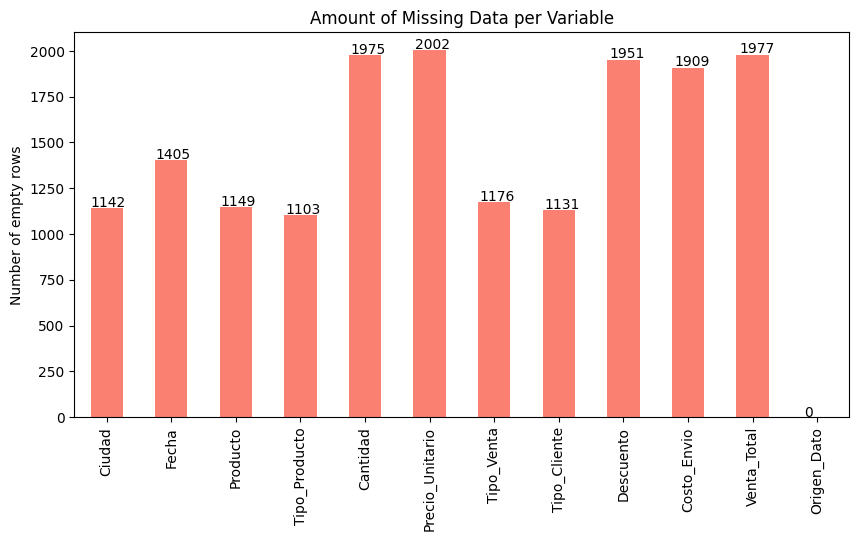

In [9]:

null = df.isnull().sum()
nulll = null[null > 0] 

if not null.empty:
    plt.figure(figsize=(10, 5))
    ax = null.plot(kind='bar', color='salmon')
    plt.title('Amount of Missing Data per Variable')
    plt.ylabel('Number of empty rows')
    
    for p in ax.patches:
        ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))
    
    plt.show()
else:
    print("Successfully There is not missing values")

In [10]:
mask_fecha = df['Fecha'].isnull()
if mask_fecha.sum() > 0:
    print(f"Ajustando las últimas {mask_fecha.sum()} fechas...")

    df['Fecha'] = df['Fecha'].fillna(method='ffill')
    df['Fecha'] = df['Fecha'].fillna(method='bfill')
    df.loc[mask_fecha, 'Origen_Dato'] = 'Proximidad Temporal'
    print("Fechas completas.")

Ajustando las últimas 1405 fechas...
Fechas completas.


C:\Users\rober\AppData\Local\Temp\ipykernel_13792\1955997734.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Fecha'] = df['Fecha'].fillna(method='ffill')
C:\Users\rober\AppData\Local\Temp\ipykernel_13792\1955997734.py:6: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Fecha'] = df['Fecha'].fillna(method='bfill')


## Fill with math

 ### Venta_Total = (Precio_Unitario * Cantidad * (1 - Descuento)) + Costo_Envio

In [11]:
# 1) We start with 'Venta_Total' 
mask_total = df['Venta_Total'].isnull() & df['Precio_Unitario'].notnull() & df['Cantidad'].notnull()
df.loc[mask_total, 'Venta_Total'] = (df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'].fillna(0)) + df['Costo_Envio'].fillna(0)
df.loc[mask_total, 'Origen_Dato'] = 'Formula matematica'
# 2) 'Costo_Envio'
mask_envio = df['Costo_Envio'].isnull() & df['Venta_Total'].notnull() & df['Precio_Unitario'].notnull() & df['Cantidad'].notnull()
subtotal = (df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'].fillna(0))
df.loc[mask_envio, 'Costo_Envio'] = df['Venta_Total'] - subtotal
df.loc[mask_envio, 'Costo_Envio'] = df.loc[mask_envio, 'Costo_Envio'].clip(lower=0)
df.loc[mask_envio, 'Origen_Dato'] = 'Formula matematica'
# 3) 'Descuento' 
mask_desc = (df['Descuento'].isnull() & df['Venta_Total'].notnull() & df['Costo_Envio'].notnull() &  df['Precio_Unitario'].notnull() & df['Cantidad'].notnull() &(df['Precio_Unitario'] * df['Cantidad'] > 0))
numerador = df['Venta_Total'] - df['Costo_Envio']
denominador = df['Precio_Unitario'] * df['Cantidad']
df.loc[mask_desc, 'Descuento'] = 1 - (numerador / denominador)
df.loc[mask_envio, 'Origen_Dato'] = 'Formula matematica'

#4) 'Precio'
mask_precio = df['Precio_Unitario'].isnull() & df['Venta_Total'].notnull() & df['Cantidad'].notnull() & (df['Cantidad'] > 0)
numerador = df['Venta_Total'] - df['Costo_Envio'].fillna(0)
denominador = df['Cantidad'] * (1 - df['Descuento'].fillna(0))
mask_precio = mask_precio & (denominador != 0)
df.loc[mask_precio, 'Precio_Unitario'] = numerador / denominador
df.loc[mask_precio, 'Origen_Dato'] = 'Formula matematica'

# 5) 'Cantidad'
mask_cantidad = df['Cantidad'].isnull() & df['Venta_Total'].notnull() & df['Precio_Unitario'].notnull() & (df['Precio_Unitario'] > 0)
numerador = df['Venta_Total'] - df['Costo_Envio'].fillna(0)
denominador = df['Precio_Unitario'] * (1 - df['Descuento'].fillna(0))
mask_cantidad = mask_cantidad & (denominador != 0)
df.loc[mask_cantidad, 'Cantidad'] = (numerador / denominador).round()
df.loc[mask_cantidad, 'Origen_Dato'] = 'Formula matematica'

print("Nulos restantes:\n", df[cols_num].isnull().sum())




Nulos restantes:
 Cantidad           9
Precio_Unitario    8
Descuento          6
Costo_Envio        5
Venta_Total        5
dtype: int64


In [12]:
gc.collect()

cols_pistas = ['Costo_Envio', 'Venta_Total', 'Cantidad', 'Descuento']
print(" Creando matriz de características optimizada...")

df_features = df[cols_pistas].copy()
for c in cols_pistas: 
    df_features[c] = pd.to_numeric(df_features[c], errors='coerce').fillna(0).astype('float32')

def imputar_con_arbol_seguro(df_target, df_features, target, features_usados):
    mask_missing = df_target[target].isnull()
    mask_exists = df_target[target].notnull()
    
    if mask_missing.sum() > 0:
        print(f"Entrenando árbol para recuperar '{target}'...")
        
        X_train = df_features.loc[mask_exists, features_usados]
        y_train = df_target.loc[mask_exists, target]
        
        X_predict = df_features.loc[mask_missing, features_usados]
        
        if len(X_train) < 50:
            print(f"Insuficientes datos para entrenar ({len(X_train)}). Se usará Moda.")
            return

        if len(X_train) > 50000:
            indices_sample = X_train.sample(50000, random_state=42).index
            X_train = X_train.loc[indices_sample]
            y_train = y_train.loc[indices_sample]
            
        clf = DecisionTreeClassifier(max_depth=10, random_state=42)
        clf.fit(X_train, y_train)
        
        preds = clf.predict(X_predict)
        
        df_target.loc[mask_missing, target] = preds
        
        if df_target['Origen_Dato'].dtype.name == 'category': 
            df_target['Origen_Dato'] = df_target['Origen_Dato'].astype('object')
        df_target.loc[mask_missing, 'Origen_Dato'] = f'IA Árbol ({target})'
        
        print(f"Recuperados {len(preds)} registros.")
    else:
        print(f"'{target}' ya estaba completo.")

imputar_con_arbol_seguro(df, df_features, 'Ciudad', ['Costo_Envio', 'Venta_Total'])

imputar_con_arbol_seguro(df, df_features, 'Tipo_Cliente', ['Cantidad', 'Descuento'])

del df_features
gc.collect()

maestro_productos = df[['Producto', 'Tipo_Producto']].dropna().drop_duplicates(subset='Producto')
mapa_prod_a_tipo = maestro_productos.set_index('Producto')['Tipo_Producto'].to_dict()

df_precios = df[['Precio_Unitario', 'Producto']].dropna()

mapa_precio_a_prod = df_precios.groupby('Precio_Unitario')['Producto'].apply(lambda x: x.mode()[0]).to_dict()

mask_falta_tipo = df['Tipo_Producto'].isnull() & df['Producto'].notnull()

if mask_falta_tipo.sum() > 0:
    print(f"Recuperando {mask_falta_tipo.sum()} Tipos basados en el Producto...")
    df.loc[mask_falta_tipo, 'Tipo_Producto'] = df.loc[mask_falta_tipo, 'Producto'].map(mapa_prod_a_tipo)
    df.loc[mask_falta_tipo, 'Origen_Dato'] = 'Lógica (Catálogo)'

mask_falta_prod = df['Producto'].isnull() & df['Precio_Unitario'].notnull()

if mask_falta_prod.sum() > 0:
    print(f"Recuperando {mask_falta_prod.sum()} Productos basados en el Precio...")
    df.loc[mask_falta_prod, 'Producto'] = df.loc[mask_falta_prod, 'Precio_Unitario'].map(mapa_precio_a_prod)
    df.loc[mask_falta_prod, 'Origen_Dato'] = 'Lógica (Precio)'
    
    mask_recursiva = df['Tipo_Producto'].isnull() & df['Producto'].notnull()
    if mask_recursiva.sum() > 0:
         df.loc[mask_recursiva, 'Tipo_Producto'] = df.loc[mask_recursiva, 'Producto'].map(mapa_prod_a_tipo)

mask_corr = df['Producto'].notnull()
df.loc[mask_corr, 'Tipo_Producto'] = df.loc[mask_corr, 'Producto'].map(mapa_prod_a_tipo)

print("Lógica de Catálogo aplicada.")
print("Nulos restantes en Producto/Tipo:")
print(df[['Producto', 'Tipo_Producto']].isnull().sum())


 Creando matriz de características optimizada...
Entrenando árbol para recuperar 'Ciudad'...
Recuperados 1142 registros.
Entrenando árbol para recuperar 'Tipo_Cliente'...
Recuperados 1131 registros.
Recuperando 1103 Tipos basados en el Producto...
Recuperando 1149 Productos basados en el Precio...
Lógica de Catálogo aplicada.
Nulos restantes en Producto/Tipo:
Producto         3
Tipo_Producto    0
dtype: int64


In [13]:
mask_residual = df['Producto'].isnull()

if mask_residual.sum() > 0:
    print(f"Limpiando las últimas {mask_residual.sum()} filas con Moda por Categoría...")
    moda_por_tipo = df.groupby('Tipo_Producto')['Producto'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Desconocido")
    
    df.loc[mask_residual, 'Producto'] = moda_por_tipo[mask_residual]
    df.loc[mask_residual, 'Origen_Dato'] = 'Estadística (Tipo)'

Limpiando las últimas 3 filas con Moda por Categoría...


C:\Users\rober\AppData\Local\Temp\ipykernel_13792\1048106720.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  moda_por_tipo = df.groupby('Tipo_Producto')['Producto'].transform(lambda x: x.mode()[0] if not x.mode().empty else "Desconocido")


In [14]:
mask_venta = df['Tipo_Venta'].isnull()
if mask_venta.sum() > 0:
    print(f"Recuperando {mask_venta.sum()} Tipos de Venta por segmento...")
    
    moda_por_cliente = df.groupby('Tipo_Cliente')['Tipo_Venta'].transform(
        lambda x: x.mode()[0] if not x.mode().empty else df['Tipo_Venta'].mode()[0])
    
    df.loc[mask_venta, 'Tipo_Venta'] = moda_por_cliente[mask_venta]
    df.loc[mask_venta, 'Origen_Dato'] = 'Estadística (Cliente)'

Recuperando 1176 Tipos de Venta por segmento...


C:\Users\rober\AppData\Local\Temp\ipykernel_13792\2056874696.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  moda_por_cliente = df.groupby('Tipo_Cliente')['Tipo_Venta'].transform(


In [15]:
# A) PRECIO UNITARIO -> Depende del PRODUCTO
# Si es una "Arepa", le ponemos el precio promedio de las "Arepas".
mask_precio = df['Precio_Unitario'].isnull()
if mask_precio.sum() > 0:
    print(f"Recuperando {mask_precio.sum()} Precios usando el Producto...")
    medianas = df.groupby('Producto')['Precio_Unitario'].transform('median')
    df.loc[mask_precio, 'Precio_Unitario'] = medianas[mask_precio]
    # Fallback por si acaso
    df['Precio_Unitario'] = df['Precio_Unitario'].fillna(df['Precio_Unitario'].median())
    df.loc[mask_precio, 'Origen_Dato'] = 'Estadística (Producto)'
# B) COSTO ENVÍO -> Depende de la CIUDAD
mask_envio = df['Costo_Envio'].isnull()
if mask_envio.sum() > 0:
    print(f"Recuperando {mask_envio.sum()} Envíos usando la Ciudad...")
    medianas = df.groupby('Ciudad')['Costo_Envio'].transform('median')
    df.loc[mask_envio, 'Costo_Envio'] = medianas[mask_envio]
    df['Costo_Envio'] = df['Costo_Envio'].fillna(df['Costo_Envio'].median())
    df.loc[mask_envio, 'Origen_Dato'] = 'Estadística (Ciudad)'
# C) DESCUENTO -> Depende del TIPO DE CLIENTE
mask_desc = df['Descuento'].isnull()
if mask_desc.sum() > 0:
    print(f"Recuperando {mask_desc.sum()} Descuentos usando el Cliente...")
    medianas = df.groupby('Tipo_Cliente')['Descuento'].transform('median')
    df.loc[mask_desc, 'Descuento'] = medianas[mask_desc]
    df['Descuento'] = df['Descuento'].fillna(0)
    df.loc[mask_desc, 'Origen_Dato'] = 'Estadística (Cliente)'

# D) CANTIDAD -> Depende del TIPO DE CLIENTE
mask_cant = df['Cantidad'].isnull()
if mask_cant.sum() > 0:
    print(f"🔹 Recuperando {mask_cant.sum()} Cantidades usando el Cliente...")
    medianas = df.groupby('Tipo_Cliente')['Cantidad'].transform('median')
    df.loc[mask_cant, 'Cantidad'] = medianas[mask_cant]
    df['Cantidad'] = df['Cantidad'].fillna(1)
    df.loc[mask_cant, 'Origen_Dato'] = 'Estadística (Cliente)'

print("Ajustando formatos finales...")
# Ajustes lógicos
df['Cantidad'] = df['Cantidad'].round()
df['Descuento'] = df['Descuento'].clip(0, 1)
df['Costo_Envio'] = df['Costo_Envio'].clip(lower=0)

# Recálculo FINAL OBLIGATORIO de Venta_Total
# Esta es la garantía de calidad: (Precio * Cantidad) + Envío = Total
df['Venta_Total'] = ((df['Precio_Unitario'] * df['Cantidad']) * (1 - df['Descuento'])) + df['Costo_Envio']

print(df.isnull().sum())

print(df['Origen_Dato'].value_counts())

Recuperando 8 Precios usando el Producto...
Recuperando 5 Envíos usando la Ciudad...


C:\Users\rober\AppData\Local\Temp\ipykernel_13792\2196062928.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medianas = df.groupby('Producto')['Precio_Unitario'].transform('median')
C:\Users\rober\AppData\Local\Temp\ipykernel_13792\2196062928.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medianas = df.groupby('Ciudad')['Costo_Envio'].transform('median')


Recuperando 6 Descuentos usando el Cliente...
🔹 Recuperando 9 Cantidades usando el Cliente...


C:\Users\rober\AppData\Local\Temp\ipykernel_13792\2196062928.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medianas = df.groupby('Tipo_Cliente')['Descuento'].transform('median')
C:\Users\rober\AppData\Local\Temp\ipykernel_13792\2196062928.py:32: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  medianas = df.groupby('Tipo_Cliente')['Cantidad'].transform('median')


Ajustando formatos finales...
Ciudad             0
Fecha              0
Producto           0
Tipo_Producto      0
Cantidad           0
Precio_Unitario    0
Tipo_Venta         0
Tipo_Cliente       0
Descuento          0
Costo_Envio        0
Venta_Total        0
Origen_Dato        0
dtype: int64
Origen_Dato
Original                   1235122
Formula matematica            7784
Proximidad Temporal           1387
Estadística (Cliente)         1190
Lógica (Precio)               1146
IA Árbol (Ciudad)             1133
IA Árbol (Tipo_Cliente)       1129
Lógica (Catálogo)             1099
Estadística (Ciudad)             5
Estadística (Tipo)               3
Estadística (Producto)           2
Name: count, dtype: int64


## Eliminacion de duplicador 

In [16]:
cols_negocio = [c for c in df.columns if c != 'Origen_Dato']
n_duplicados = df.duplicated(subset=cols_negocio, keep='first').sum()

if n_duplicados >0:
    print(f'Se detectaron {n_duplicados} filas duplicados')
    filas_antes = len(df)
    df = df.drop_duplicates(subset=cols_negocio, keep='first').reset_index(drop=True)
    filas_despues = len(df)

    print(f"Se eliminaron {filas_antes - filas_despues} fias")
    print(f"Total de filas actuales {filas_despues}")

    

Se detectaron 4113 filas duplicados
Se eliminaron 4113 fias
Total de filas actuales 1245887


# Normalizacion

## CREAR DIMENSIÓN PRODUCTO 

In [19]:
cols_prod = ['Producto', 'Tipo_Producto']
dim_producto = df[cols_prod].drop_duplicates().reset_index(drop=True)

dim_producto['ID_Producto'] = dim_producto.index + 1

dim_producto['SKU'] = (
    dim_producto['Producto'].str[:3].str.upper() + "-" + 
    dim_producto['Tipo_Producto'].str[:3].str.upper() + "-" + 
    dim_producto['ID_Producto'].astype(str).str.zfill(3)
)

dim_producto = dim_producto[['ID_Producto', 'SKU', 'Producto', 'Tipo_Producto']]

print(f"Tabla 'dim_producto' creada con {len(dim_producto)} productos únicos.")

Tabla 'dim_producto' creada con 24 productos únicos.


##  CREAR DIMENSIÓN CLIENTE/GEOGRAFÍA

In [17]:
cols_cli = ['Ciudad', 'Tipo_Cliente']
dim_cliente = df[cols_cli].drop_duplicates().reset_index(drop=True)

dim_cliente['ID_Cliente'] = dim_cliente.index + 1

dim_cliente = dim_cliente[['ID_Cliente', 'Ciudad', 'Tipo_Cliente']]

print(f"Tabla 'dim_cliente' creada con {len(dim_cliente)} perfiles de clientes.")

Tabla 'dim_cliente' creada con 354 perfiles de clientes.


## Crear tabla ventas

In [ ]:
df_fact = df.merge(dim_producto, on=['Producto', 'Tipo_Producto'], how='left')
df_fact = df_fact.merge(dim_cliente, on=['Ciudad', 'Tipo_Cliente'], how='left')

cols_fact = [
    'ID_Producto', 
    'ID_Cliente', 
    'Fecha', 
    'Tipo_Venta', 
    'Cantidad', 
    'Precio_Unitario', 
    'Descuento', 
    'Costo_Envio', 
    'Venta_Total',
    'Origen_Dato'
]

fact_ventas = df_fact[cols_fact].copy()
fact_ventas.index.name = 'ID_Venta'
fact_ventas = fact_ventas.reset_index()
fact_ventas['ID_Venta'] = fact_ventas['ID_Venta'] + 1 

print(f"Tabla 'fact_ventas' creada con {len(fact_ventas)} transacciones.")

Tabla 'fact_ventas' creada con 1245887 transacciones.


## Exportaciones a CSV

In [21]:
dim_producto.to_csv('dim_producto.csv', index=False)
dim_cliente.to_csv('dim_cliente.csv', index=False)
fact_ventas.to_csv('fact_ventas.csv', index=False)

## To upload SQL

In [22]:
load_dotenv(override=True) 
db_user = os.getenv('DB_USER')
db_password = os.getenv('DB_PASSWORD')
db_host = os.getenv('DB_HOST')
db_port = os.getenv('DB_PORT')
db_name = os.getenv('DB_NAME')
if not db_port:
    print("Advertencia: No se detectó DB_PORT en .env, usando 5432 por defecto.")
    db_port = "5432"

if not db_user or not db_password:
    print("ERROR CRÍTICO: No se encontraron usuario o contraseña en el archivo .env")
else:
    try:
        db_url = f"postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}"
        engine = create_engine(db_url)
        print(f"Motor de conexión creado para: {db_host}:{db_port}/{db_name}")
        def cargar_dataframe_a_sql(df, nombre_tabla):
            try:
                print(f"Insertando datos en '{nombre_tabla}'...")
                df.to_sql(nombre_tabla, engine, if_exists='append', index=False, method='multi', chunksize=1000)
                
                print(f"{len(df)} filas insertadas en '{nombre_tabla}'.")
            except Exception as e:
                print(f" Error cargando '{nombre_tabla}': {e}")
                print(" Pista: Revisa que los nombres de columnas en Python coincidan EXACTAMENTE con DBeaver.")
                
        if 'dim_producto' in locals(): cargar_dataframe_a_sql(dim_producto, 'dim_producto')
        if 'dim_cliente' in locals():  cargar_dataframe_a_sql(dim_cliente, 'dim_cliente')
        if 'fact_ventas' in locals():  cargar_dataframe_a_sql(fact_ventas, 'fact_ventas')
        
        print("\n ¡PROCESO FINALIZADO!")
        
    except Exception as e:
        print(f"Error fatal en la conexión: {e}")

Motor de conexión creado para: localhost:5432/ventas
Insertando datos en 'dim_producto'...
24 filas insertadas en 'dim_producto'.
Insertando datos en 'dim_cliente'...
354 filas insertadas en 'dim_cliente'.
Insertando datos en 'fact_ventas'...
1245887 filas insertadas en 'fact_ventas'.

 ¡PROCESO FINALIZADO!
